In [1]:
import pandas as pd
import numpy as np
from typing import Optional
from scipy.optimize import minimize
import plotly.graph_objects as go
import plotly.express as px
import openpyxl

Task 1 (a):

In [53]:
# Data Input
rf1,rf2,rf3 = 0.0025, 0.0125, 0.02 #rf = 25bps, 125bps, 200bps
mu = np.array([0.02,0.07,0.15,0.20]).reshape(-1,1)
S = np.diag([0.05,0.12,0.17,0.25]) # standard deviation diagnol matrix
R = np.array([[1,0.3,0.3,0.3],
              [0.3,1,0.6,0.6],
              [0.3,0.6,1,0.6],
              [0.3,0.6,0.6,1]])
Cov = S@R@S  ## Covariance Matrix
Inversed_Cov = np.linalg.inv(Cov) ## Inverse of Covariance Matrix
ones = np.ones((4, 1)) ## Ones Matrix

In [54]:
def tangent_portfolio_weight(rf):
    w = (Inversed_Cov@(mu-rf*ones))/(ones.T@Inversed_Cov@(mu-rf*ones))
    return w

w1 = tangent_portfolio_weight(rf1)
w2 = tangent_portfolio_weight(rf2)
w3 = tangent_portfolio_weight(rf3)

sigma1 = np.sqrt(w1.T@Cov@w1)
sigma2 = np.sqrt(w2.T@Cov@w2)
sigma3 = np.sqrt(w3.T@Cov@w3)

tangency_portfolio_weight_summary = pd.DataFrame({'25bps':w1.flatten(),'125bps':w2.flatten(),'200bps':w3.flatten()},index=['A', 'B', 'C','D'])
tangency_portfolio_weight_summary

,25bps,125bps,200bps
A,0.187416,-1.928805,3.549557
B,-0.166481,-0.946643,1.073001
C,0.663185,2.538414,-2.316081
D,0.315880,1.337034,-1.306476


In [55]:
tangency_portfolio_sigma_summary = pd.DataFrame({'25bps':sigma1.flatten(),'125bps':sigma2.flatten(),'200bps':sigma3.flatten()},index=['sigma_pi'])
tangency_portfolio_sigma_summary

,25bps,125bps,200bps
sigma_pi,0.162749,0.59255,0.538335


Task 1 (b):

In [62]:
class PortfolioOptimization:
    def __init__(
        self,
        returns,
        cov_matrix,
        risk_free_rate: float,
    ):
        self.number_of_assets = 4
        self.risk_free_rate = risk_free_rate
        self.expected_returns = returns
        self.cov_matrix = cov_matrix

    def _portfolio_variance(self, weights: np.ndarray) -> float:
        """Calculate portfolio variance."""
        return weights.T @ self.cov_matrix @ weights

    def _portfolio_return(self, weights: np.ndarray) -> float:
        """Calculate portfolio expected return."""
        return np.sum(weights * self.expected_returns)

    def _negative_sharpe_ratio(self, weights: np.ndarray) -> float:
        """Calculate negative Sharpe ratio (for minimization)."""
        ret = self._portfolio_return(weights)
        std = np.sqrt(self._portfolio_variance(weights))
        return -(ret - self.risk_free_rate) / std if std != 0 else None

    def _positive_sharpe_ratio(self, weights: np.ndarray) -> float:
        """Calculate negative Sharpe ratio (for minimization)."""
        ret = self._portfolio_return(weights)
        std = np.sqrt(self._portfolio_variance(weights))
        return (ret - self.risk_free_rate) / std if std != 0 else None
        
    def _negative_return(self, weights: np.ndarray) -> float:
        """Calculate negative return (for minimization)."""
        return -self._portfolio_return(weights)
        
    def _positive_return(self, weights: np.ndarray) -> float:
        """Calculate negative return (for minimization)."""
        return self._portfolio_return(weights)
        
    def optimize_portfolio(
        self,
        maximize_sharpe: Optional[str] = None,
        maximize_return: Optional[str] = None,
        target_risk: Optional[float] = None,
    ):

        initial_weights = np.ones(self.number_of_assets) / self.number_of_assets  ## set as equal weights initially
        constraints = [{"type": "eq", "fun": lambda x: np.sum(x) - 1}]  ## sum to 1

        ##three types of optimization directions
        if maximize_sharpe == 'Maximize':  
            objective = self._negative_sharpe_ratio
            
        elif maximize_sharpe == 'Minimize':  
            objective = self._positive_sharpe_ratio
            
        elif target_risk is not None:  
            if maximize_return == 'Maximize':
                objective = self._negative_return
            if maximize_return == 'Minimize':
                objective = self._positive_return

            constraints.append(
                {
                    "type": "eq",
                    "fun": lambda x: target_risk**2 - self._portfolio_variance(x),
                }
            )

        result = minimize(
            objective,
            initial_weights,
            method="SLSQP",
            constraints=constraints,
        )

        portfolio_return = self._portfolio_return(result.x)  ## result here is an object, .x helps to get the real result
        portfolio_risk = np.sqrt(self._portfolio_variance(result.x))
        sharpe_ratio = (
            (portfolio_return - self.risk_free_rate) / portfolio_risk
            if portfolio_risk != 0
            else 0
        )

        return {
            "weights": result.x,
            "expected_return": portfolio_return,
            "expected_risk": portfolio_risk,
            "sharpe_ratio": sharpe_ratio,
        }

    def plot_efficient_frontier(self, opt_sharpe, scenario, num_portfolios=100,maximize_return: Optional[str]=None):  ## remove ms for a moment
        """
        Plot the efficient frontier with max Sharpe portfolio. However, for 200bps, the sharpe ratio is negative, I still draw the graph
        to illustrate the idea, but it's not an efficient frontier. 
        """
        # Results of efficient frontier
        results = []
        target_risks = np.linspace(0.05, 0.6, num=num_portfolios)  # Risk range for efficient frontier

        for target_risk in target_risks:
            result = self.optimize_portfolio(target_risk=target_risk,maximize_return=maximize_return)
            results.append(
                {
                    "expected_return": result["expected_return"],
                    "expected_risk": result["expected_risk"],
                    "sharpe_ratio": result["sharpe_ratio"],
                }
            )

        # Create a DataFrame of results
        frontier = pd.DataFrame(results)
        
        # Plot efficient frontier using lines
        fig = go.Figure(
            data=go.Scatter(
                x=frontier["expected_risk"], 
                y=frontier["expected_return"], 
                mode='markers', 
                marker=dict(
                    color=frontier["sharpe_ratio"],
                    colorbar=dict(
                        title="Sharpe Ratio",
                        tickvals=[frontier["sharpe_ratio"].min(), frontier["sharpe_ratio"].max()],
                        ticktext=[f"{frontier['sharpe_ratio'].min():.2f}", f"{frontier['sharpe_ratio'].max():.2f}"],
                    ),
                    symbol='cross'),
                hovertemplate="Expected Volatility: %{x}<br>Expected Return: %{y}<extra></extra>",
            )
        )

        # Plot max/min Sharpe ratio
        fig.add_trace(
            go.Scatter(
                x=[opt_sharpe["expected_risk"]],
                y=[opt_sharpe["expected_return"]],
                mode="markers",
                marker=dict(color="red", size=20, symbol="star"),
                hovertemplate="Tangency Portfolio<br>Expected Volatility: %{x}<br>Expected Return: %{y}<extra></extra>",
            )
        )

        
        title="Efficient Frontier with Tangency Portfolio for "
        if maximize_return=='Minimize':
            title="Inefficient Frontier with Tangency Portfolio for "
        # Update layout for title and labels
        fig.update_layout(
            title=title + scenario,
            xaxis_title="Expected Volatility (%)",
            yaxis_title="Expected Return (%)",
            width=800,
            height=600,
            showlegend=False,
        )

        # Show spikes on both axes
        fig.update_xaxes(showspikes=True)
        fig.update_yaxes(showspikes=True)

        # Show the plot
        fig.show()

{'weights': array([ 0.18675441, -0.1667737 ,  0.66378978,  0.3162295 ]), 'expected_return': np.float64(0.1548752974316013), 'expected_risk': np.float64(0.1628847494332755), 'sharpe_ratio': np.float64(0.9354792143632863)}


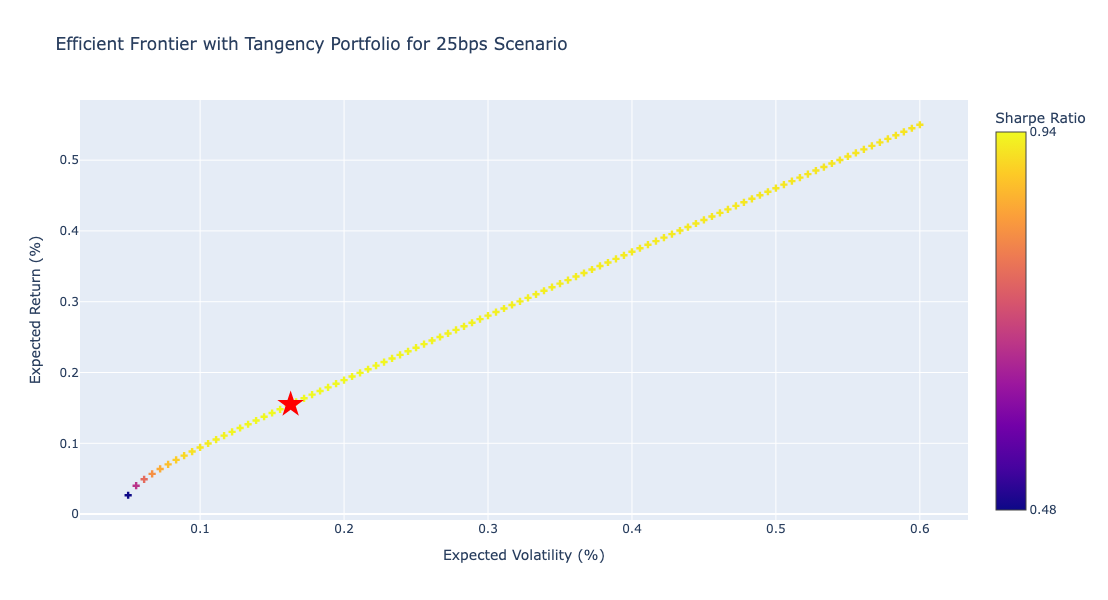

In [63]:
mu = pd.Series([0.02,0.07,0.15,0.20])
Cov = pd.DataFrame(Cov)
optimizer_1 = PortfolioOptimization(returns=mu,cov_matrix=Cov,risk_free_rate=rf1)
ms_1 = optimizer_1.optimize_portfolio(maximize_sharpe='Maximize')
optimizer_1.plot_efficient_frontier(ms_1,maximize_return='Maximize',scenario='25bps Scenario')

{'weights': array([-1.89809505, -0.93366411,  2.5010674 ,  1.33069176]), 'expected_return': np.float64(0.5379800737542793), 'expected_risk': np.float64(0.5865831071603157), 'sharpe_ratio': np.float64(0.8958322654366235)}


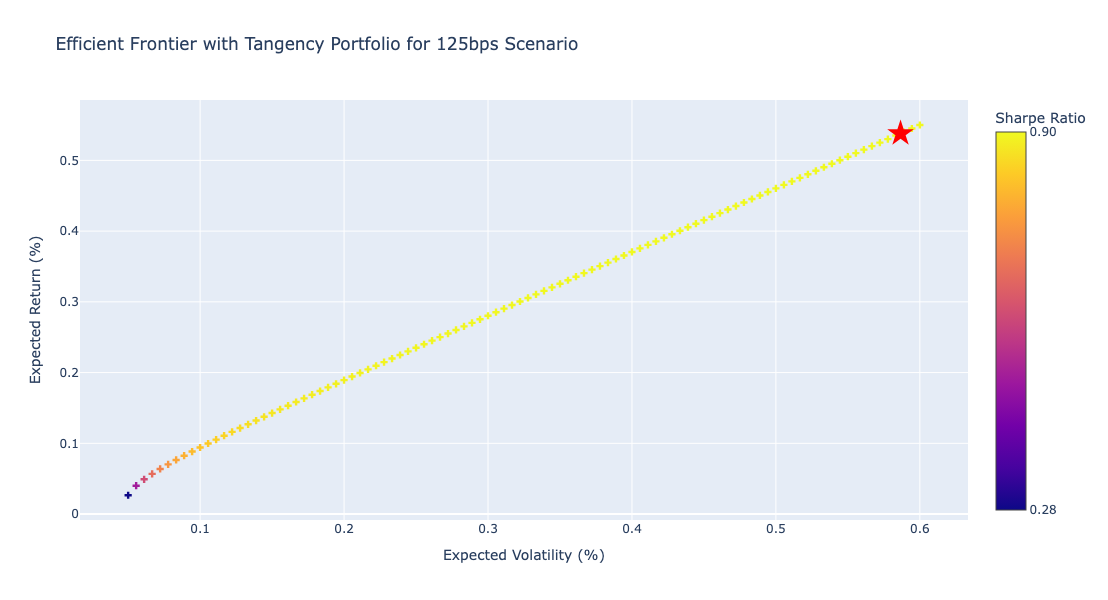

In [64]:
optimizer_2 = PortfolioOptimization(returns=mu,cov_matrix=Cov,risk_free_rate=rf2)
ms_2 = optimizer_2.optimize_portfolio(maximize_sharpe='Maximize')
optimizer_2.plot_efficient_frontier(ms_2,maximize_return='Maximize',scenario='125bps Scenario')

{'weights': array([ 3.57717814,  1.0792081 , -2.33729632, -1.31908992]), 'expected_return': np.float64(-0.46732430156898447), 'expected_risk': np.float64(0.5435986025572418), 'sharpe_ratio': np.float64(-0.8964782088777876)}

Notice: When exploring the solution for Task1(b), I used the tangency weights to calculate the sharpe ratio at tangency point. I noticed the sharpe ratio for 200bps scenario is negative, which means the portfolio has a negative slope and tangent to the opposite side of the efficient frontier that consists of inefficient portfolios. I aware of that and decided to draw the plot to illustrate the inefficiency of the portfolio.


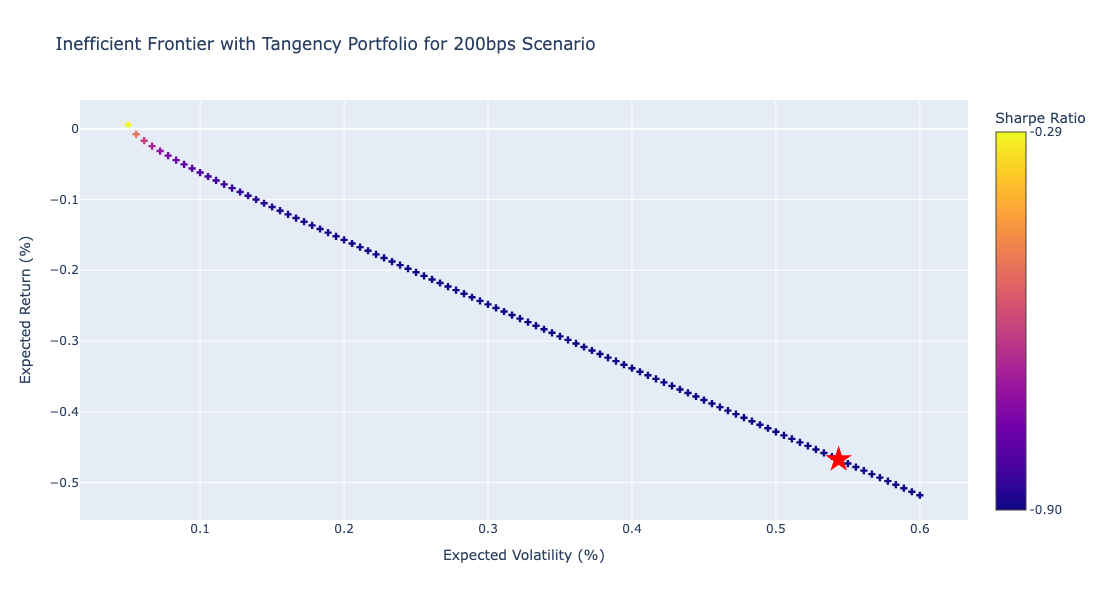

In [65]:
optimizer_3 = PortfolioOptimization(returns=mu,cov_matrix=Cov,risk_free_rate=rf3)
ms_3 = optimizer_3.optimize_portfolio(maximize_sharpe='Minimize')
print('Notice: When exploring the solution for Task1(b), I used the tangency weights to calculate the sharpe ratio at tangency point. I noticed the sharpe ratio for 200bps scenario is negative, which means the portfolio has a negative slope and tangent to the opposite side of the efficient frontier that consists of inefficient portfolios. I aware of that and decided to draw the plot to illustrate the inefficiency of the portfolio.')
optimizer_3.plot_efficient_frontier(ms_3,maximize_return='Minimize',scenario='200bps Scenario')

Task 1 (c):

In [9]:
sharpe_for_200bps = (w3.T@mu - rf3)/(np.sqrt(w3.T@Cov@w3))
sharpe_for_200bps

array([[-0.89647872]])

As the sharpe ratio when rf=200bps is -0.8964, which is negative, the investor will reduce their excess return for each additional unit of risk taken. In this case, the investor would better off to just hold 100% risk-free portfolio. 

Task 2

We can identify the analytical solution for the optimal weights through Lagrange method.
Based on the constraints, we can form the Lagrange functin with two Lagrange multipliers $\lambda$ and $\gamma$: 

$L(w,\lambda,\gamma) = \frac{1}{2}w'\Sigma w+\lambda(m-w'\mu)+\gamma(1-w'1)$

Then, we take derivative respect to w:

$\frac{\partial L(w,\lambda,\gamma)}{\partial w} = \Sigma w-\lambda\mu-\gamma1$

Let $\Sigma w-\lambda\mu-\gamma1=0$, we can get the optimal weight $w^{*}$ in terms of $\lambda$ and $\gamma$:

$w^{*} =\Sigma ^{-1}(\lambda\mu+\gamma1)$

Then, to find $\lambda$ and $\gamma$, we can plug $w^{*}$ back to the two constraints:

$\lambda\mu'\Sigma^{-1}\mu+\gamma\mu'\Sigma^{-1}1 = m$

$\lambda1'\Sigma^{-1}\mu+\gamma1'\Sigma^{-1}1 = 1$

To make it easy for calculation, we can define three scalars:

$A = 1'\Sigma^{-1}1$

$B = 1'\Sigma^{-1}\mu$

$C = \mu'\Sigma^{-1}\mu$

so the previous two equations can be rewrote as:

$C\lambda + B\gamma= m$

$B\lambda + A\gamma= 1$

Then:

$\lambda = \frac{Am-B}{AC-B^{2}}$

$\gamma = \frac{C-Bm}{AC-B^{2}}$

The scalars A,B,C are able to be caluclated through the given asset information, and then we will be able to use A,B,C to get $\lambda
$ and $\gamma$. Then, we can plug them back into $w^{*} =\Sigma ^{-1}(\lambda\mu+\gamma1)$ to get the optimal weight. The calculation process and results are show below.


In [77]:
m = 0.07
ones = np.ones((4, 1))
mu = np.array([0.05,0.07,0.15,0.22]).reshape(-1,1)
S = np.diag([0.07,0.28,0.25,0.31]) # standard deviation diagnol matrix

R1 = np.array([[1,0.4,0.3,0.3],
              [0.4,1,0.27,0.42],
              [0.3,0.27,1,0.5],
              [0.3,0.42,0.5,1]])
Cov1 = S@R1@S  ##Covariance Matrix
Inversed_Cov1 = np.linalg.inv(Cov1)

R2 = R1*1.3
R2[R2> 0.99] = 0.99
np.fill_diagonal(R2, 1)
Cov2 = S@R2@S  ##Covariance Matrix
Inversed_Cov2 = np.linalg.inv(Cov2)

R3 = R1*1.8
R3[R3> 0.99] = 0.99
np.fill_diagonal(R3, 1)
Cov3 = S@R3@S  ##Covariance Matrix
Inversed_Cov3 = np.linalg.inv(Cov3)

In [42]:
def optimal_weight(Inversed_Cov):
    A = ones.T@Inversed_Cov@ones
    B = ones.T@Inversed_Cov@mu
    C = mu.T@Inversed_Cov@mu
    lam = (A*m-B)/(A*C-B**2)  ## lambda
    gamma = (C-B*m)/(A*C-B**2)
    w = Inversed_Cov@(lam*mu+gamma*ones)
    return w

optimal_weight_1 = optimal_weight(Inversed_Cov1)
optimal_weight_2 = optimal_weight(Inversed_Cov2)
optimal_weight_3 = optimal_weight(Inversed_Cov3)
optimal_weight_summary = pd.DataFrame({'x1':optimal_weight_1.flatten(),'x1.3':optimal_weight_2.flatten(),'x1.8':optimal_weight_3.flatten()},index=['A', 'B', 'C','D'])
optimal_weight_summary


,x1,x1.3,x1.8
A,0.924135,0.996471,1.450878
B,-0.072894,-0.135126,-0.407703
C,0.054730,0.012412,-0.507053
D,0.094029,0.126243,0.463879


Task 3

In [3]:
NASDAQ100 = pd.read_csv(r'/Users/peterfeng/Downloads/CQF/Exam 1/Data Files/E1_NASDAQ100.csv')
SNP500 = pd.read_csv(r'/Users/peterfeng/Downloads/CQF/Exam 1/Data Files/E1_SP500.csv')

(a)

In [21]:
NASDAQ100['LogReturn'] = np.log(NASDAQ100['Closing Price']/NASDAQ100['Closing Price'].shift(1))
NASDAQ100['Ret_10D'] = np.log(NASDAQ100['Closing Price'].shift(-11)/NASDAQ100['Closing Price'].shift(-1)) ## just imagine to calculate for row x, we need to use value from row x-11 divided by value from x-1
NASDAQ100['VaR_10D'] = 2.33*(NASDAQ100['LogReturn'].rolling(window=21).std())*np.sqrt(10) 
NASDAQ100['Negative VaR_10D Threshold'] = -NASDAQ100['VaR_10D']
NASDAQ100.loc[NASDAQ100['Ret_10D']<NASDAQ100['Negative VaR_10D Threshold'],'Breach'] = 'Breach' 
NASDAQ100.loc[NASDAQ100['Ret_10D']>=NASDAQ100['Negative VaR_10D Threshold'],'Breach'] = 'No Breach' 

In [26]:
SNP500['LogReturn'] = np.log(SNP500['Closing Price'] / SNP500['Closing Price'].shift(1))
SNP500['Ret_10D'] = np.log(SNP500['Closing Price'].shift(-11)/SNP500['Closing Price'].shift(-1))
SNP500['VaR_10D'] = 2.33*(SNP500['LogReturn'].rolling(window=21).std())*np.sqrt(10)
SNP500['Negative VaR_10D Threshold'] = -SNP500['VaR_10D']
SNP500.loc[SNP500['Ret_10D']<SNP500['Negative VaR_10D Threshold'],'Breach'] = 'Breach' 
SNP500.loc[SNP500['Ret_10D']>=SNP500['Negative VaR_10D Threshold'],'Breach'] = 'No Breach' 

In [27]:
NASDAQ100_breach_count = sum(NASDAQ100['Breach']=='Breach')
NASDAQ100_breach_percentage = round(NASDAQ100_breach_count/(NASDAQ100['VaR_10D'].count())*100,2)  
print(f"In NASDAQ100, there are {NASDAQ100_breach_count} breaches, which is {NASDAQ100_breach_percentage}% of all comparisons made. (denominator is 1673-21=1652 due to the 21-day rolling window when clculating daily VaR)")

SNP500_breach_count = sum(SNP500['Breach']=='Breach')
SNP500_breach_percentage = round(SNP500_breach_count/(SNP500['VaR_10D'].count())*100,2) 
print(f"In SNP500, there are {SNP500_breach_count} breaches, which is {SNP500_breach_percentage}% of all comparisons made. (denominator is 1673-21=1652 due to the 21-day rolling window when clculating daily VaR)")


In NASDAQ100, there are 45 breaches, which is 2.72% of all comparisons made. (denominator is 1673-21=1652 due to the 21-day rolling window when clculating daily VaR)
In SNP500, there are 62 breaches, which is 3.75% of all comparisons made. (denominator is 1673-21=1652 due to the 21-day rolling window when clculating daily VaR)


(b)

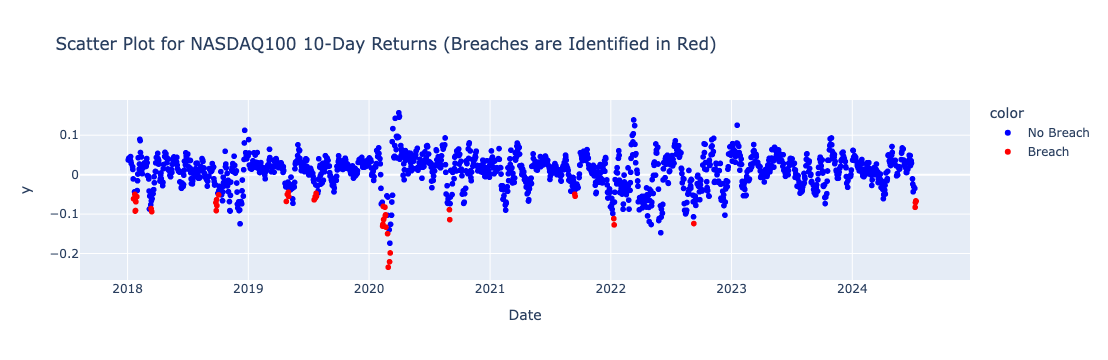

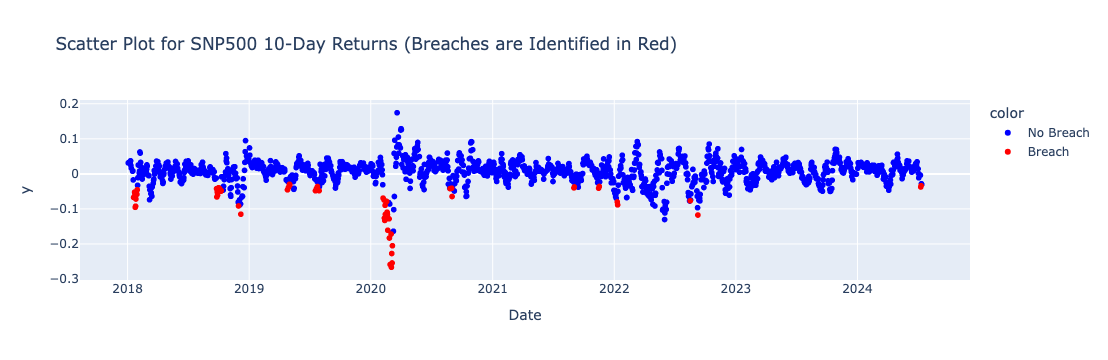

In [28]:
# Create the dot plot
NASDAQ100_fig = px.scatter(NASDAQ100, 
                 x=NASDAQ100['Date'], 
                 y=NASDAQ100['Ret_10D'],
                 color= NASDAQ100['Breach'],
                 color_discrete_sequence=['red', 'blue'],
                 title='Scatter Plot for NASDAQ100 10-Day Returns (Breaches are Identified in Red)')
NASDAQ100_fig.show()

SNP500_fig = px.scatter(SNP500, 
                 x=SNP500['Date'], 
                 y=SNP500['Ret_10D'],
                 color= SNP500['Breach'],
                 color_discrete_sequence=['red', 'blue'],
                 title='Scatter Plot for SNP500 10-Day Returns (Breaches are Identified in Red)')
SNP500_fig.show()

(c)

In [29]:
NASDAQ100_Breach_Summary = NASDAQ100.loc[NASDAQ100['Breach'] == 'Breach',['Date', 'Closing Price', 'LogReturn', 'VaR_10D', 'Ret_10D']]
NASDAQ100_Breach_Summary.rename(columns={'Closing Price': 'ClosingPrice'}, inplace=True)
NASDAQ100_Breach_Summary

,Date,ClosingPrice,LogReturn,VaR_10D,Ret_10D
32,2018-01-19,6834.330078,0.003364,0.045841,-0.061257
34,2018-01-23,6963.459961,0.008245,0.046035,-0.049980
35,2018-01-24,6919.350098,-0.006355,0.048418,-0.092363
36,2018-01-25,6916.299805,-0.000441,0.048256,-0.090909
37,2018-01-26,7022.970215,0.015305,0.049911,-0.068775
38,2018-01-29,6988.319824,-0.004946,0.051699,-0.055911
68,2018-03-13,7046.509766,-0.011936,0.079783,-0.085993
70,2018-03-15,7030.970215,-0.001423,0.077612,-0.093890
204,2018-09-25,7563.189941,0.001911,0.055395,-0.071033
205,2018-09-26,7563.089844,-0.000013,0.053119,-0.091273


In [30]:
SNP500_Breach_Summary = SNP500.loc[SNP500['Breach'] == 'Breach',['Date', 'Closing Price', 'LogReturn', 'VaR_10D', 'Ret_10D']]
SNP500_Breach_Summary.rename(columns={'Closing Price': 'ClosingPrice'}, inplace=True)
SNP500_Breach_Summary

,Date,ClosingPrice,LogReturn,VaR_10D,Ret_10D
32,2018-01-19,2810.300049,0.004376,0.030954,-0.067166
33,2018-01-22,2832.969971,0.008034,0.031004,-0.052048
34,2018-01-23,2839.129883,0.002172,0.030470,-0.056502
35,2018-01-24,2837.540039,-0.000560,0.030917,-0.095363
36,2018-01-25,2839.250000,0.000602,0.030674,-0.092309
...,...,...,...,...,...
1034,2022-01-11,4713.069824,0.009118,0.071909,-0.088392
1184,2022-08-17,4274.040039,-0.007264,0.076787,-0.076854
1200,2022-09-09,4067.360107,0.015156,0.094803,-0.117416
1658,2024-07-09,5576.979980,0.000741,0.025148,-0.037393


(d)

In [31]:
NASDAQ100_breaches_during_Covid = len(NASDAQ100_Breach_Summary.loc[(NASDAQ100_Breach_Summary['Date'] >= '2020-02-01') & (NASDAQ100_Breach_Summary['Date'] <= '2020-03-30')])
NASDAQ100_breaches_during_correction =  len(NASDAQ100_Breach_Summary.loc[(NASDAQ100_Breach_Summary['Date'] >= '2021-01-01') & (NASDAQ100_Breach_Summary['Date'] <= '2022-12-31')])

SNP500_breaches_during_Covid = len(SNP500_Breach_Summary.loc[(SNP500_Breach_Summary['Date'] >= '2020-02-01') & (SNP500_Breach_Summary['Date'] <= '2020-03-30')])
SNP500_breaches_during_correction =  len(SNP500_Breach_Summary.loc[(SNP500_Breach_Summary['Date'] >= '2021-01-01') & (SNP500_Breach_Summary['Date'] <= '2022-12-31')])


In [32]:
print(f"During Covid, there are {NASDAQ100_breaches_during_Covid} breaches for NASDAQ100, and {SNP500_breaches_during_Covid} breaches for SNP500, which indicates that SNP500 is riskier. During the corretction from 2021 to 2022, there are {NASDAQ100_breaches_during_correction} breaches for NASDAQ100 and {SNP500_breaches_during_correction} breaches for SNP500, which indicates that SNP500 is riskier.")


During Covid, there are 12 breaches for NASDAQ100, and 18 breaches for SNP500, which indicates that SNP500 is riskier. During the corretction from 2021 to 2022, there are 5 breaches for NASDAQ100 and 8 breaches for SNP500, which indicates that SNP500 is riskier.
